In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency

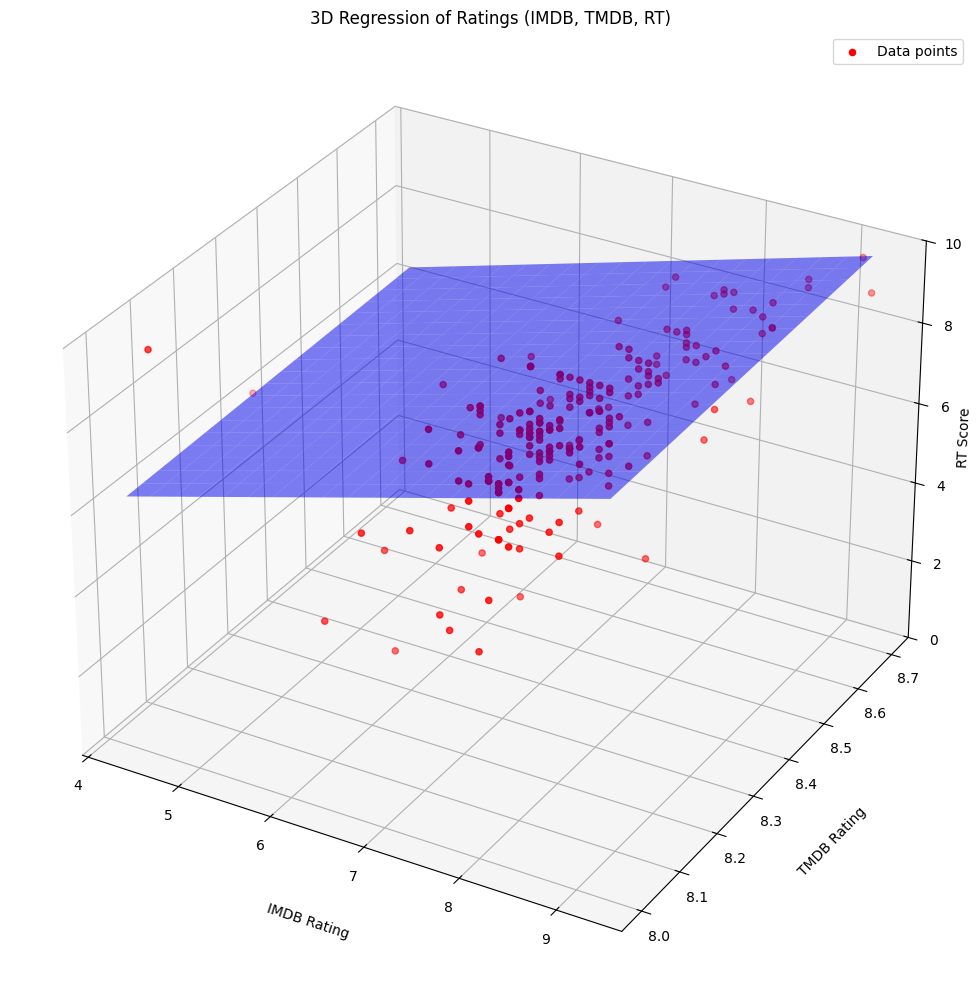

Regression Coefficients:
IMDB Rating Coefficient: 0.6597724261209627
TMDB Rating Coefficient: 0.2959734225226122
Intercept: 1.087456020042902
R-squared: 0.10758310625737011


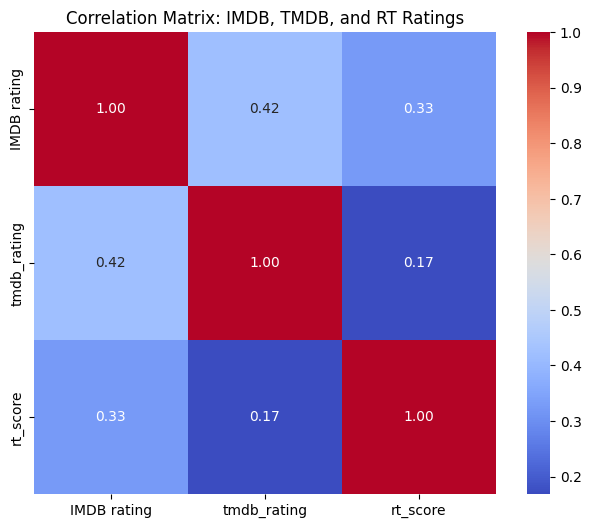

Correlation Matrix:
             IMDB rating  tmdb_rating  rt_score
IMDB rating     1.000000     0.419031  0.326129
tmdb_rating     0.419031     1.000000  0.168413
rt_score        0.326129     0.168413  1.000000

Covariance Matrix:
             IMDB rating  tmdb_rating  rt_score
IMDB rating     0.315213     0.036586  0.218798
tmdb_rating     0.036586     0.024185  0.031297
rt_score        0.218798     0.031297  1.427916


In [3]:
# (1): Comparsion of ratings

movies_data = pd.read_csv("C:/Users/H1th1/Desktop/STA141B/final project/fetching_popular_movies.csv")

# Filter the necessary columns for regression
ratings_data = movies_data[['IMDB rating', 'tmdb_rating', 'rt_score']].dropna()

# Convert ratings to numerical types
ratings_data = ratings_data.astype(float)

# Prepare the data for 3D regression
X = ratings_data[['IMDB rating', 'tmdb_rating']].values  # Independent variables: IMDB and TMDB ratings
y = ratings_data['rt_score'].values  # Dependent variable: RT score

# Fit the regression model
model = LinearRegression()
model.fit(X, y)

# Generate predictions for the regression plane
x_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 20)
y_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 20)
x_grid, y_grid = np.meshgrid(x_range, y_range)
z_pred = model.predict(np.c_[x_grid.ravel(), y_grid.ravel()]).reshape(x_grid.shape)

# Adjust the figure size to make all labels visible
fig = plt.figure(figsize=(16, 12))  # Increase overall figure size
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], y, c='r', label='Data points')
ax.plot_surface(x_grid, y_grid, z_pred, alpha=0.5, color='blue')

# Set labels
ax.set_xlabel('IMDB Rating', labelpad=20)  # Add more padding for visibility
ax.set_ylabel('TMDB Rating', labelpad=20)
ax.set_zlabel('RT Score', labelpad=0)  # Ensure the z-label is clearly visible
ax.set_title('3D Regression of Ratings (IMDB, TMDB, RT)')

ax.set_zlim(0, 10)  # Ensure RT scores fit within the z-axis range
plt.legend()
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)  # Ensure proper spacing around the plot
plt.show()

# Numeric results: Coefficients and R-squared value. Interpretation might be troublesome
coefficients = model.coef_
intercept = model.intercept_
r_squared = model.score(X, y)

print("Regression Coefficients:")
print(f"IMDB Rating Coefficient: {coefficients[0]}")
print(f"TMDB Rating Coefficient: {coefficients[1]}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_squared}")


# Calculate the correlation matrix for IMDB rating, TMDB rating, and RT score
correlation_matrix = ratings_data.corr()

# Plot the heatmap for the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True, square=True)
plt.title('Correlation Matrix: IMDB, TMDB, and RT Ratings')
plt.show()

# Print the correlation matrix for reference
print("Correlation Matrix:")
print(correlation_matrix)
print("")

# Calculate the covariance matrix for IMDB rating, TMDB rating, and RT score
covariance_matrix = ratings_data.cov()

# Display the covariance matrix
print("Covariance Matrix:")
print(covariance_matrix)

Budget Trends by Decade:
                mean      median  count
Decade                                 
1920.0  3.125000e+06   3125000.0      2
1930.0  1.500000e+06   1500000.0      2
1940.0  1.338332e+06    938631.0      6
1950.0  1.101082e+07   1400000.0     13
1960.0  3.425868e+06   2400000.0      8
1970.0  9.187500e+06   5750000.0      8
1980.0  1.798300e+07  17200000.0     14
1990.0  1.077253e+08  20000000.0     30
2000.0  5.297500e+07  26500000.0     24
2010.0  3.685192e+08  19000000.0     48
2020.0  7.464000e+07  42900000.0     19


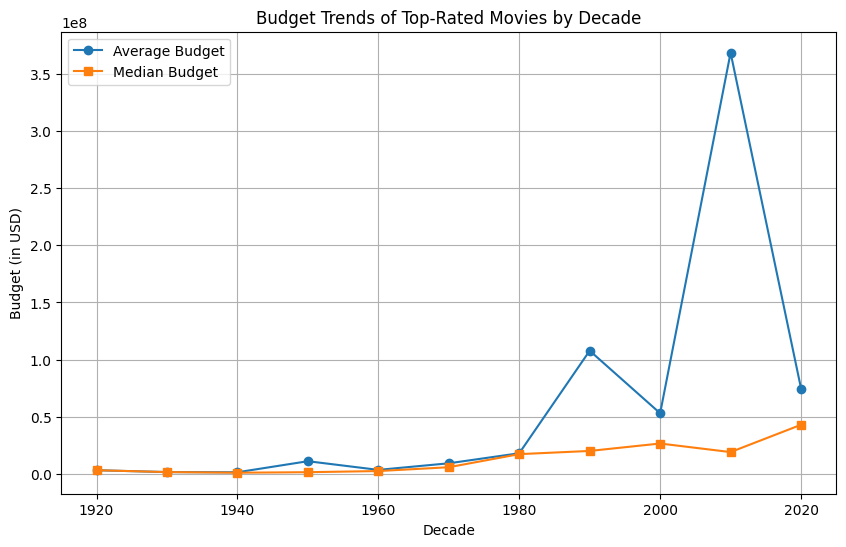

In [4]:
# (2): Budget over decades
# Extract decade from release year
movies_data['Release Date'] = movies_data['Release Date'].astype(str)

# Extract the release year as the last 4 digits from the "Release Date" column
movies_data['Release Year'] = movies_data['Release Date'].str.extract(r'(\d{4})').astype(float)

# Calculate the decade
movies_data['Decade'] = (movies_data['Release Year'] // 10) * 10

# Group by decade and calculate statistics
budget_trends = movies_data.groupby('Decade')['Budget'].agg(['mean', 'median', 'count']).dropna()

# Display budget trends
print("Budget Trends by Decade:")
print(budget_trends)

# Plot the trends
plt.figure(figsize=(10, 6))
plt.plot(budget_trends.index, budget_trends['mean'], label='Average Budget', marker='o')
plt.plot(budget_trends.index, budget_trends['median'], label='Median Budget', marker='s')

# Customize the plot
plt.xlabel('Decade')
plt.ylabel('Budget (in USD)')
plt.title('Budget Trends of Top-Rated Movies by Decade')
plt.legend()
plt.grid(True)
plt.show()

Top 10 Directors by Average Gross Revenue:
                            mean        median  count
Director                                             
Anthony Russo       2.425927e+09  2.425927e+09      2
Joseph Kosinski     1.495696e+09  1.495696e+09      1
David Yates         1.342500e+09  1.342500e+09      1
Todd Phillips       1.078959e+09  1.078959e+09      1
Peter Jackson       9.882220e+08  9.382429e+08      3
Jon Favreau         9.817083e+08  9.817083e+08      1
Lee Unkrich         8.146412e+08  8.146412e+08      1
Alfonso Cuarón      8.084854e+08  8.084854e+08      1
Joaquim Dos Santos  6.908247e+08  6.908247e+08      1
Christopher Nolan   6.175874e+08  7.855761e+08      6

Top 10 Production Companies by Average Gross Revenue:
                                             mean        median  count
Production Co                                                         
Marvel Studios                       2.425927e+09  2.425927e+09      2
Don Simpson/Jerry Bruckheimer Films  1.49

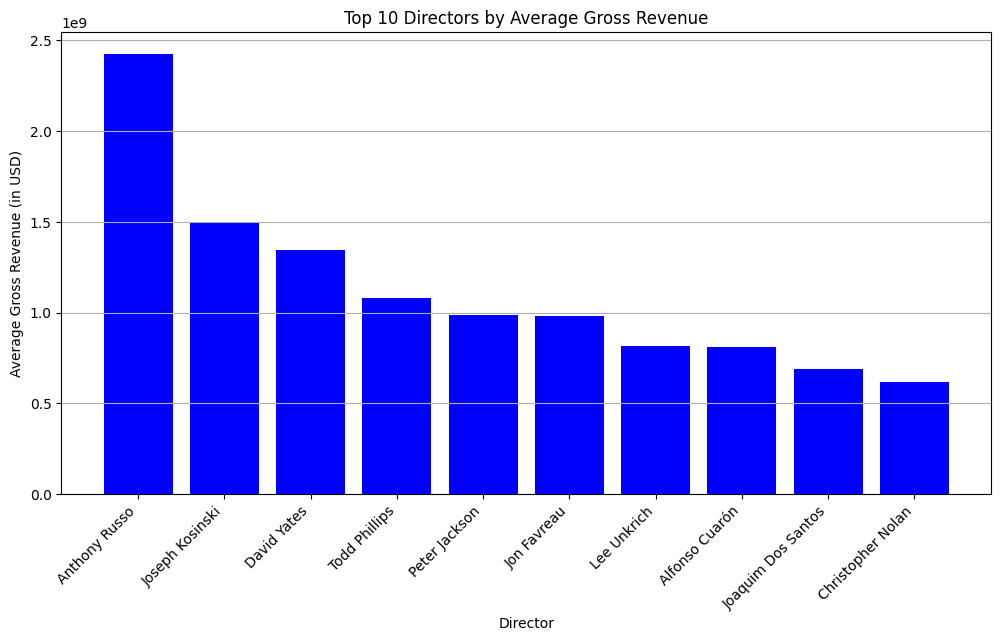

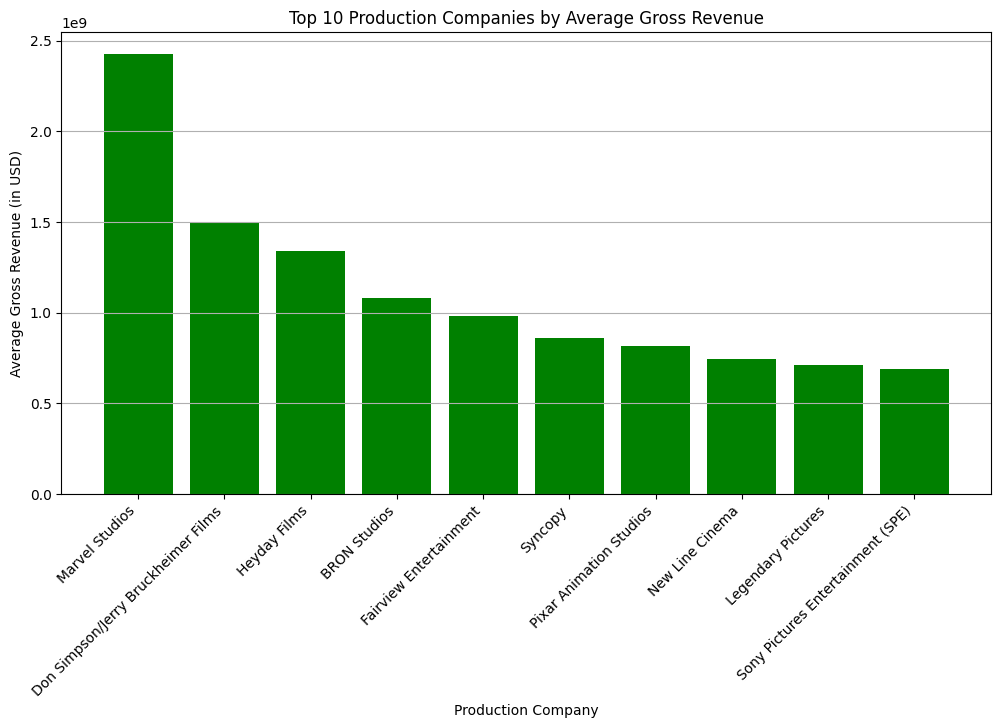

In [5]:
# (3) What director or production company has been the most successful throughout the years?
# Define success by calculating average gross revenue and movie count for Directors
director_success = movies_data.groupby('Director')['Gross worldwide'].agg(['mean', 'median', 'count']).sort_values(by='mean', ascending=False)

# Define success by calculating average gross revenue and movie count for Production Companies
company_success = movies_data.groupby('Production Co')['Gross worldwide'].agg(['mean', 'median', 'count']).sort_values(by='mean', ascending=False)

# Display the top 10 directors by average gross revenue
print("Top 10 Directors by Average Gross Revenue:")
print(director_success.head(10))

# Display the top 10 production companies by average gross revenue
print("\nTop 10 Production Companies by Average Gross Revenue:")
print(company_success.head(10))

# Plot the top 10 directors
plt.figure(figsize=(12, 6))
top_directors = director_success.head(10)
plt.bar(top_directors.index, top_directors['mean'], color='blue')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Director')
plt.ylabel('Average Gross Revenue (in USD)')
plt.title('Top 10 Directors by Average Gross Revenue')
plt.grid(axis='y')
plt.show()

# Plot the top 10 production companies
plt.figure(figsize=(12, 6))
top_companies = company_success.head(10)
plt.bar(top_companies.index, top_companies['mean'], color='green')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Production Company')
plt.ylabel('Average Gross Revenue (in USD)')
plt.title('Top 10 Production Companies by Average Gross Revenue')
plt.grid(axis='y')
plt.show()

In [11]:
# (4): NLP on the descriptions of movies using keywords
from sklearn.feature_extraction.text import TfidfVectorizer

# Extract the descriptions column
descriptions = movies_data['Description'].dropna()

# Convert descriptions into TF-IDF vectors
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=100)
tfidf_matrix = tfidf_vectorizer.fit_transform(descriptions)

# Get the feature names (words)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Sum up the TF-IDF scores for each word across all documents
word_scores = tfidf_matrix.sum(axis=0).A1  # Convert to 1D array
word_scores_df = pd.DataFrame({'Word': feature_names, 'Score': word_scores})

# Sort words by score in descending order
top_words = word_scores_df.sort_values(by='Score', ascending=False).head(10)

# Display the top 10 words
print("Top 10 Informative Words:")
print(top_words)

Top 10 Informative Words:
      Word      Score
43    life  18.237427
99   young  16.310662
96   world  13.174471
51     man  13.033083
18  family  12.414660
91     war  11.523501
80   story  11.187462
98   years  11.173055
83    time  10.568362
59     new   9.454620


In [14]:
# Cluster movies based on these words
from sklearn.cluster import KMeans

# Step 1: Filter top 50 movies by IMDB rating
top_movies = movies_data.sort_values(by='IMDB rating', ascending=False).head(50)

# Step 2: Extract movie titles and descriptions
movie_titles = top_movies['Title'].dropna()
descriptions = top_movies['Description'].dropna()

# Step 3: Convert descriptions into TF-IDF vectors
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=100)
tfidf_matrix = tfidf_vectorizer.fit_transform(descriptions)

# Step 4: Identify top 10 informative words
feature_names = tfidf_vectorizer.get_feature_names_out()
word_scores = tfidf_matrix.sum(axis=0).A1
word_scores_df = pd.DataFrame({'Word': feature_names, 'Score': word_scores})
top_words = word_scores_df.sort_values(by='Score', ascending=False).head(10)['Word'].values

# Step 5: Reduce the TF-IDF matrix to top 10 words
reduced_tfidf_matrix = tfidf_matrix[:, [feature_names.tolist().index(word) for word in top_words]]

# Step 6: Perform KMeans clustering
num_clusters = 5  # Define the number of clusters
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
clusters = kmeans.fit_predict(reduced_tfidf_matrix)

# Step 7: Analyze clusters and associated keywords
cluster_dict = {i: [] for i in range(num_clusters)}
cluster_keywords = {i: np.zeros(len(top_words)) for i in range(num_clusters)}

for idx, cluster in enumerate(clusters):
    cluster_dict[cluster].append(movie_titles.iloc[idx])
    cluster_keywords[cluster] += reduced_tfidf_matrix[idx].toarray()[0]

# Normalize keyword scores per cluster
for cluster_id in cluster_keywords:
    cluster_keywords[cluster_id] /= len(cluster_dict[cluster_id])

# Step 8: Display clusters and associated top 3 keywords
print("Clusters and Associated Keywords:")
for cluster_id, movies in cluster_dict.items():
    print(f"\nCluster {cluster_id + 1}:")
    print("  Movies:")
    for movie in movies:
        print(f"    - {movie}")
    # Get the top 3 keywords for the cluster
    top_3_indices = np.argsort(cluster_keywords[cluster_id])[::-1][:3]
    top_3_keywords = [top_words[i] for i in top_3_indices]
    print("  Keywords:", top_3_keywords)

Clusters and Associated Keywords:

Cluster 1:
  Movies:
    - Schindlers List
    - The Matrix
    - Life Is Beautiful
    - The Pianist
    - The Usual Suspects
  Keywords: ['story', 'war', 'family']

Cluster 2:
  Movies:
    - BTS World Tour Love Yourself in Seoul
    - David Attenborough A Life on Our Planet
    - Earthlings
  Keywords: ['world', 'life', 'man']

Cluster 3:
  Movies:
    - The Godfather
    - Persona
    - The Godfather Part II
    - Harakiri
    - Spirited Away
    - The Best of Youth
    - Whiplash
  Keywords: ['family', 'young', 'crime']

Cluster 4:
  Movies:
    - The Shawshank Redemption
    - The Lord of the Rings The Return of the King
    - The Lord of the Rings The Fellowship of the Ring
    - Pulp Fiction
    - The Lord of the Rings The Two Towers
    - Inception
    - Fight Club
    - Forrest Gump
    - The Good the Bad and the Ugly
    - Interstellar
    - SpiderMan Across the SpiderVerse
    - Its a Wonderful Life
    - City of God
    - Seven Samurai
  